In [60]:
import re
import os
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
from colorama import Fore
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from tld import get_tld, is_tld
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from app.ml.Preprocessing import TextCleaner, NumericFeatures
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer

In [38]:
print(os.getcwd())

c:\Users\Lenovo\Documents\02 Programming\CPF Government app\project\backend


In [4]:
os.chdir("../..")
print(os.getcwd())

c:\Users\Lenovo\Documents\02 Programming\CPF Government app\project\backend


In [98]:
# change working directory to project root
import os
print(os.getcwd())
os.chdir("../..")
print(os.getcwd())

c:\Users\Lenovo\Documents\02 Programming\CPF Government app\project\backend
c:\Users\Lenovo\Documents\02 Programming\CPF Government app


In [3]:

import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from app.ml.Preprocessing import TextCleaner
from app.ml.Preprocessing import NumericFeatures
from app.ml.Preprocessing import SourceTypeEncoder
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


# Explore, Clean, and Combine Datasets

### sms_Phishing_Dataset

In [39]:
df = pd.read_csv("app/ml/datasets/sms_Phishing_Dataset.csv")

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5971 entries, 0 to 5970
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   LABEL   5971 non-null   object
 1   TEXT    5971 non-null   object
 2   URL     5971 non-null   object
 3   EMAIL   5971 non-null   object
 4   PHONE   5971 non-null   object
dtypes: object(5)
memory usage: 233.4+ KB


In [41]:
df.head()

,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Your opinion about me? 1. Over 2. Jada 3. Kusr...,No,No,No
1,ham,What's up? Do you want me to come online? If y...,No,No,No
2,ham,So u workin overtime nigpun?,No,No,No
3,ham,"Also sir, i sent you an email about how to log...",No,No,No
4,Smishing,Please Stay At Home. To encourage the notion o...,No,No,No


In [42]:
df["LABEL"] = df["LABEL"].replace("Spam", "spam")

In [43]:
df["LABEL"] = df["LABEL"].replace("Smishing", "smishing")

In [44]:
df["label"] = df["LABEL"]

In [45]:
df['label'].value_counts()

label
ham         4844
smishing     638
spam         489
Name: count, dtype: int64

In [46]:
df["text"] = df["TEXT"]

In [47]:
df = df[["text", "label"]]

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5971 entries, 0 to 5970
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5971 non-null   object
 1   label   5971 non-null   object
dtypes: object(2)
memory usage: 93.4+ KB


In [49]:
df.head()

,text,label
0,Your opinion about me? 1. Over 2. Jada 3. Kusr...,ham
1,What's up? Do you want me to come online? If y...,ham
2,So u workin overtime nigpun?,ham
3,"Also sir, i sent you an email about how to log...",ham
4,Please Stay At Home. To encourage the notion o...,smishing


In [50]:
#count duplicates
df.duplicated().sum()

20

In [51]:
df.drop_duplicates(inplace=True)

In [52]:
df.to_csv("app/ml/datasets/cleaned_sms_phishing_dataset.csv", index=False)

# Preprocessing

In [53]:
df = pd.read_csv("app/ml/datasets/cleaned_sms_phishing_dataset.csv")

In [54]:
#encode labels
label_map = {
    "ham": 0,
    "spam": 1,
    "smishing": 2
}

df["label_num"] = df["label"].map(label_map)

In [55]:
MAX_LEN = 5000

df["text"] = df["text"].astype(str).str.slice(0, MAX_LEN)

In [56]:
df.value_counts("label")

label
ham         4834
smishing     628
spam         489
Name: count, dtype: int64

In [57]:
df.head()

,text,label,label_num
0,Your opinion about me? 1. Over 2. Jada 3. Kusr...,ham,0
1,What's up? Do you want me to come online? If y...,ham,0
2,So u workin overtime nigpun?,ham,0
3,"Also sir, i sent you an email about how to log...",ham,0
4,Please Stay At Home. To encourage the notion o...,smishing,2


# Pipeline

In [58]:
# text pipeline
text_pipeline = Pipeline([
    ("Cleaner", TextCleaner()),
    ("Vectorizer", TfidfVectorizer(max_features=5000))
])

#numericFeatures pipeline
numfeatures_pipeline = Pipeline([
    ("extract_features", NumericFeatures()),
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("Scale", StandardScaler())
])

# Combine all pipelines
preprocessor = ColumnTransformer([
    ("text", text_pipeline, "text"),
    ("numeric_features", numfeatures_pipeline, "text")
])

In [61]:
# combine preprocessor with classifier
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced"))
])

In [62]:
#Stratified split
X = df[["text"]]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [63]:
# fit and save model
model_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('numeric_features', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

In [64]:
joblib.dump(model_pipeline, "app/ml/models/sms_phishing_model_pipeline_LR.joblib")

['app/ml/models/sms_phishing_model_pipeline_LR.joblib']

In [65]:
model = joblib.load("app/ml/models/sms_phishing_model_pipeline_LR.joblib")

In [66]:
y_pred = model.predict(X_test)

In [67]:
classification_rep = classification_report(y_test, y_pred, target_names=label_map.keys())
conf_matrix = confusion_matrix(y_test, y_pred)
print("Classification Report:")
print(classification_rep)
print("Confusion Matrix:")
print(conf_matrix)

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       967
        spam       0.73      0.82      0.77        98
    smishing       0.89      0.86      0.87       126

    accuracy                           0.96      1191
   macro avg       0.87      0.89      0.88      1191
weighted avg       0.96      0.96      0.96      1191

Confusion Matrix:
[[953  13   1]
 [  5  80  13]
 [  2  16 108]]


In [35]:
classification_rep = classification_report(y_test, y_pred, target_names=label_map.keys())
conf_matrix = confusion_matrix(y_test, y_pred)
print("Classification Report:")
print(classification_rep)
print("Confusion Matrix:")
print(conf_matrix)

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       967
        spam       0.80      0.62      0.70        98
    smishing       0.88      0.80      0.84       126

    accuracy                           0.95      1191
   macro avg       0.88      0.81      0.84      1191
weighted avg       0.94      0.95      0.94      1191

Confusion Matrix:
[[967   0   0]
 [ 23  61  14]
 [ 10  15 101]]


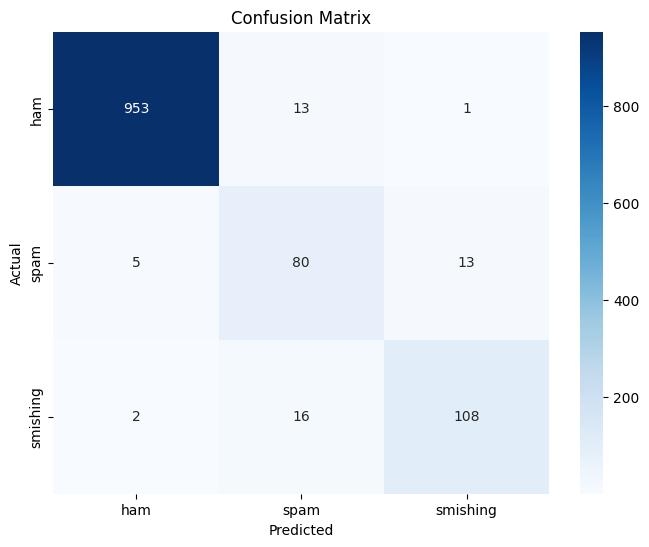

In [69]:
# plot conf matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from huggingface_hub import upload_file

upload_file(
    path_or_fileobj="app/ml/models/sms_phishing_model_pipeline_LR.joblib",   # your file
    path_in_repo="model.joblib",      # how it appears online
    repo_id="aboudiua/sms_phishing_model_pipeline1",
    token=""
)

Processing Files (1 / 1): 100%|██████████|  283kB /  283kB, 52.1kB/s  
New Data Upload: 100%|██████████|  146kB /  146kB, 52.1kB/s  


CommitInfo(commit_url='https://huggingface.co/aboudiua/sms_phishing_model_pipeline1/commit/0a6c7977c5e9bda5fb9bcefddca4ff357a4cd304', commit_message='Upload model.joblib with huggingface_hub', commit_description='', oid='0a6c7977c5e9bda5fb9bcefddca4ff357a4cd304', pr_url=None, repo_url=RepoUrl('https://huggingface.co/aboudiua/sms_phishing_model_pipeline1', endpoint='https://huggingface.co', repo_type='model', repo_id='aboudiua/sms_phishing_model_pipeline1'), pr_revision=None, pr_num=None)